# UJIndoorLoc Wi-Fi Indoor Positioning
### Machine Learning Based Floor Classification

This project investigates Wi-Fi fingerprint-based indoor floor
classification using the UJIndoorLoc dataset.

The reference work is reproduced using the specified machine learning
pipeline, and an additional machine learning model is introduced as an
extension.

## 1. Objective

The objective of this project is to predict the floor of a building using
Wi-Fi Received Signal Strength Indicator (RSSI) measurements.

The project consists of two components:

1. Reproduce the machine learning models reported in the reference work.
2. Extend the work by implementing an additional machine learning model
   that was not used in the reference.

The experiments are performed independently for each building.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score

## 2. Dataset

The UJIndoorLoc dataset consists of Wi-Fi fingerprint measurements
collected from indoor environments.

Each fingerprint contains RSSI measurements corresponding to Wi-Fi
access points. The objective is to determine the floor associated with
each fingerprint.

For this project, the three buildings available in the processed dataset
are considered separately.

The Wi-Fi RSSI measurements are used as input features and `FLOOR` is used
as the classification target.

In [22]:
data = {}

for b in [0, 1, 2]:
    df = pd.read_csv(f"building{b}_floor.csv")

    data[b] = (
        df.drop(columns=["FLOOR"]),
        df["FLOOR"]
    )

    print(
        f"Building {b}: "
        f"{data[b][0].shape[0]} samples, "
        f"{data[b][0].shape[1]} features"
    )

Building 0: 5245 samples, 200 features
Building 1: 4904 samples, 207 features
Building 2: 9078 samples, 203 features


## 3. Data Preprocessing

The cleaned datasets are loaded separately for each building.

Duplicate samples are removed before model evaluation. This is important
because identical fingerprints appearing in different cross-validation
folds could result in overly optimistic performance estimates.

In [23]:
for b in data:
    X, y = data[b]

    temp = pd.concat([X, y], axis=1)

    before = len(temp)
    temp = temp.drop_duplicates().reset_index(drop=True)

    data[b] = (
        temp.drop(columns=["FLOOR"]),
        temp["FLOOR"]
    )

    print(
        f"Building {b}: "
        f"{before - len(temp)} duplicates removed"
    )

Building 0: 3 duplicates removed
Building 1: 72 duplicates removed
Building 2: 68 duplicates removed


In [24]:
summary = []

for b, (X, y) in data.items():
    summary.append({
        "Building": b,
        "Samples": len(X),
        "Features": X.shape[1],
        "Floors": y.nunique(),
        "Classes": sorted(y.unique())
    })

summary_df = pd.DataFrame(summary)
summary_df

,Building,Samples,Features,Floors,Classes
0,0,5242,200,4,"[0, 1, 2, 3]"
1,1,4832,207,4,"[0, 1, 2, 3]"
2,2,9010,203,5,"[0, 1, 2, 3, 4]"


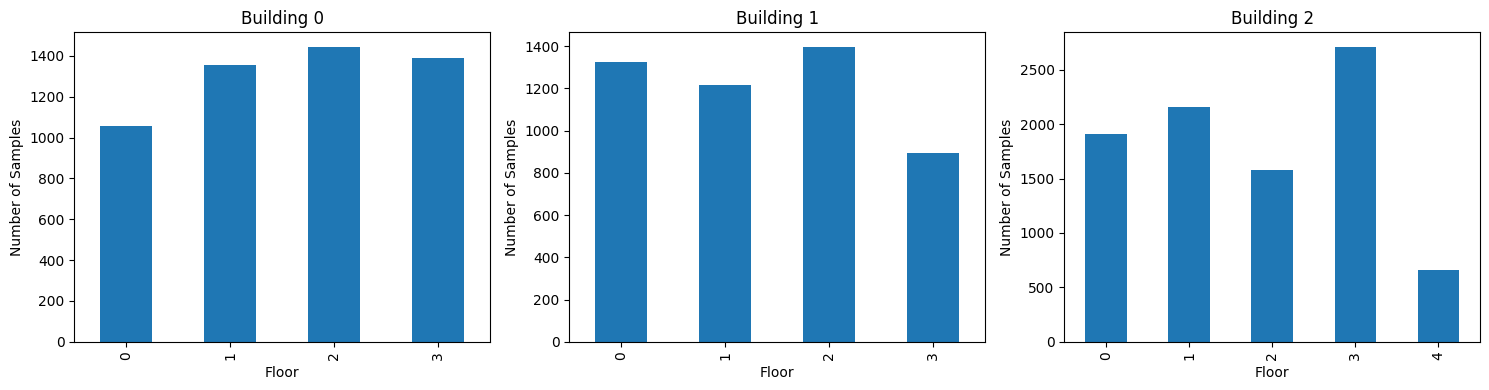

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (b, (X, y)) in zip(axes, data.items()):
    y.value_counts().sort_index().plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(f"Building {b}")
    ax.set_xlabel("Floor")
    ax.set_ylabel("Number of Samples")

plt.tight_layout()
plt.show()

The class distribution varies across buildings because each building
contains a different number of floors and samples per floor.


## 4. Experimental Setup

Each building is treated as an independent classification problem.

A stratified 10-fold cross-validation strategy is used for evaluation.
Stratification ensures that the floor classes are represented across
the folds.

The following metrics are used:

- Accuracy
- Macro F1-score

The same cross-validation procedure is applied to all models to ensure
a fair comparison.

In [26]:
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

## 5. Gradient Boosting

Gradient Boosting is an ensemble learning technique that combines
multiple decision trees sequentially.

Each subsequent tree attempts to correct errors made by the previous
trees. This allows the model to learn complex relationships between
Wi-Fi RSSI measurements and floor classes.

Gradient Boosting is evaluated independently for each building using
10-fold stratified cross-validation.

In [27]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

results = []

for b, (X, y) in data.items():

    model = GradientBoostingClassifier(
        random_state=42
    )

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1
    )

    results.append({
        "Building": b,
        "Model": "Gradient Boosting",
        "Accuracy": scores["test_accuracy"].mean(),
        "F1": scores["test_f1_macro"].mean()
    })

    print(
        f"Building {b}: "
        f"Accuracy = {scores['test_accuracy'].mean():.4f}, "
        f"F1 = {scores['test_f1_macro'].mean():.4f}"
    )

Building 0: Accuracy = 0.9954, F1 = 0.9953
Building 1: Accuracy = 0.9930, F1 = 0.9928
Building 2: Accuracy = 0.9982, F1 = 0.9982


## 6. Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm
that attempts to find decision boundaries that separate different
classes.

An RBF kernel is used in this experiment. Feature standardization is
performed before classification using a pipeline.

The SVM is evaluated independently for each building using 10-fold
stratified cross-validation.

In [28]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

for b, (X, y) in data.items():

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf"))
    ])

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1
    )

    results.append({
        "Building": b,
        "Model": "SVM",
        "Accuracy": scores["test_accuracy"].mean(),
        "F1": scores["test_f1_macro"].mean()
    })

    print(
        f"Building {b}: "
        f"Accuracy = {scores['test_accuracy'].mean():.4f}, "
        f"F1 = {scores['test_f1_macro'].mean():.4f}"
    )

Building 0: Accuracy = 0.9901, F1 = 0.9901
Building 1: Accuracy = 0.9950, F1 = 0.9950
Building 2: Accuracy = 0.9917, F1 = 0.9909


## 7. Random Forest — Additional Model

Random Forest is an ensemble learning algorithm that combines the
predictions of multiple decision trees.

Random Forest is introduced as the additional model for the extension
component of the project because it provides a different ensemble-based
approach to classification.

The model is evaluated using the same datasets, cross-validation
procedure and evaluation metrics as the other models.

In [29]:
from sklearn.ensemble import RandomForestClassifier

for b, (X, y) in data.items():

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1
    )

    results.append({
        "Building": b,
        "Model": "Random Forest",
        "Accuracy": scores["test_accuracy"].mean(),
        "F1": scores["test_f1_macro"].mean()
    })

    print(
        f"Building {b}: "
        f"Accuracy = {scores['test_accuracy'].mean():.4f}, "
        f"F1 = {scores['test_f1_macro'].mean():.4f}"
    )

Building 0: Accuracy = 0.9983, F1 = 0.9982
Building 1: Accuracy = 0.9981, F1 = 0.9981
Building 2: Accuracy = 0.9998, F1 = 0.9998


In [30]:
results_df = pd.DataFrame(results)

results_df["Accuracy (%)"] = results_df["Accuracy"] * 100
results_df["F1 (%)"] = results_df["F1"] * 100

results_df[
    ["Building", "Model", "Accuracy (%)", "F1 (%)"]
]

,Building,Model,Accuracy (%),F1 (%)
0,0,Gradient Boosting,99.542094,99.529602
1,1,Gradient Boosting,99.296152,99.282662
2,2,Gradient Boosting,99.822420,99.823778
3,0,SVM,99.008070,99.009678
4,1,SVM,99.503277,99.496679
5,2,SVM,99.167592,99.090450
6,0,Random Forest,99.828317,99.816657
7,1,Random Forest,99.813707,99.814451
8,2,Random Forest,99.977802,99.979026


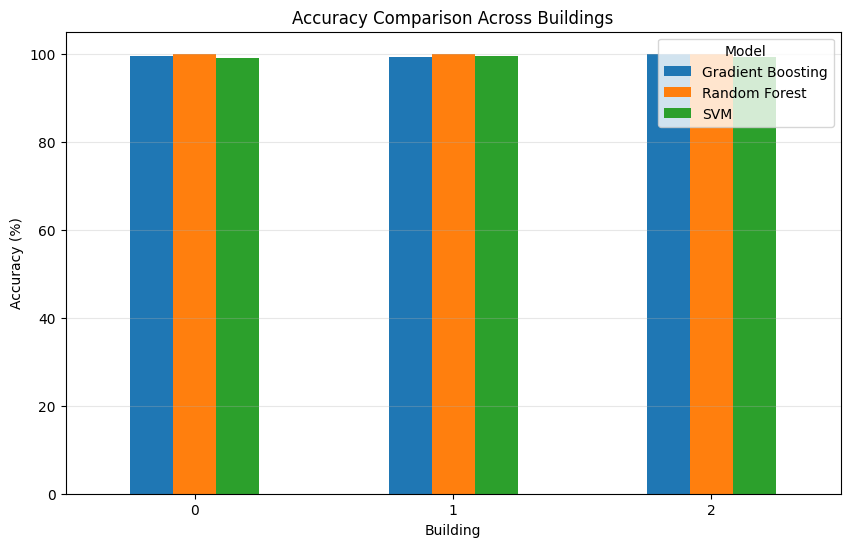

In [31]:
accuracy_table = results_df.pivot(
    index="Building",
    columns="Model",
    values="Accuracy (%)"
)

accuracy_table.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Accuracy Comparison Across Buildings")
plt.xlabel("Building")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Model")
plt.show()

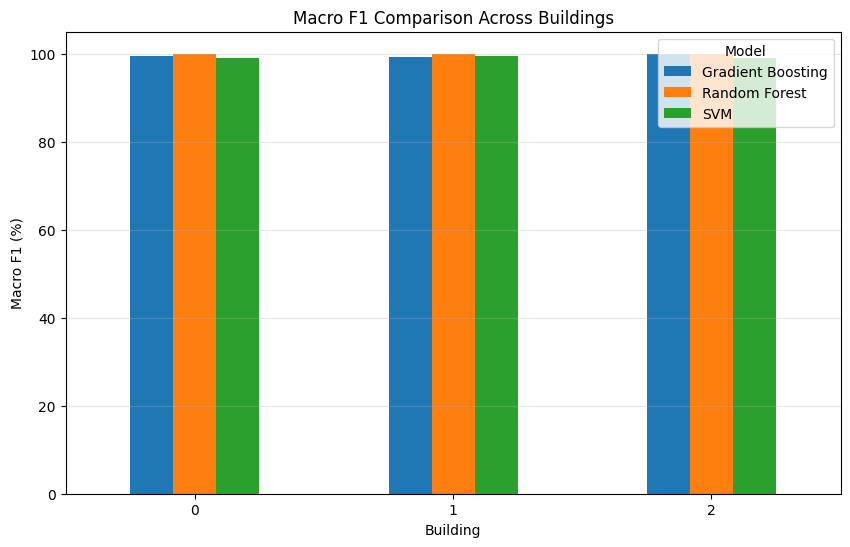

In [32]:
f1_table = results_df.pivot(
    index="Building",
    columns="Model",
    values="F1 (%)"
)

f1_table.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Macro F1 Comparison Across Buildings")
plt.xlabel("Building")
plt.ylabel("Macro F1 (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Model")
plt.show()

In [33]:
model_summary = results_df.groupby("Model")[
    ["Accuracy (%)", "F1 (%)"]
].mean().sort_values(
    "Accuracy (%)",
    ascending=False
)

model_summary

,Accuracy (%),F1 (%)
Model,,
Random Forest,99.873276,99.870045
Gradient Boosting,99.553555,99.545348
SVM,99.226313,99.198936


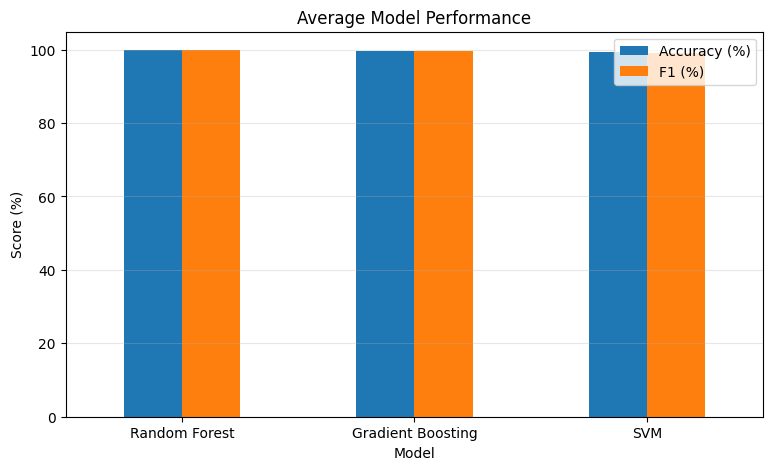

In [34]:
model_summary.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Model Performance")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [35]:
best_models = (
    results_df
    .loc[
        results_df.groupby("Building")["Accuracy (%)"].idxmax()
    ]
    .reset_index(drop=True)
)

best_models

,Building,Model,Accuracy,F1,Accuracy (%),F1 (%)
0,0,Random Forest,0.998283,0.998167,99.828317,99.816657
1,1,Random Forest,0.998137,0.998145,99.813707,99.814451
2,2,Random Forest,0.999778,0.999790,99.977802,99.979026


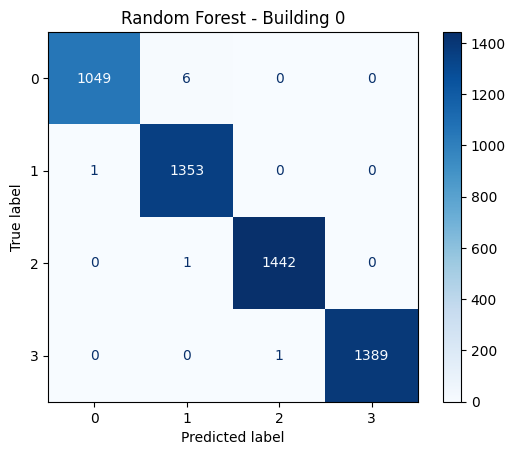

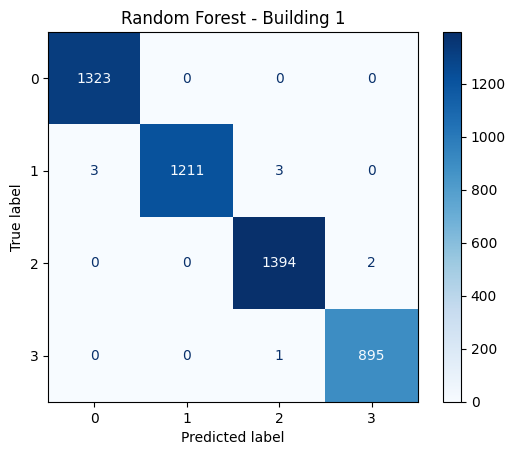

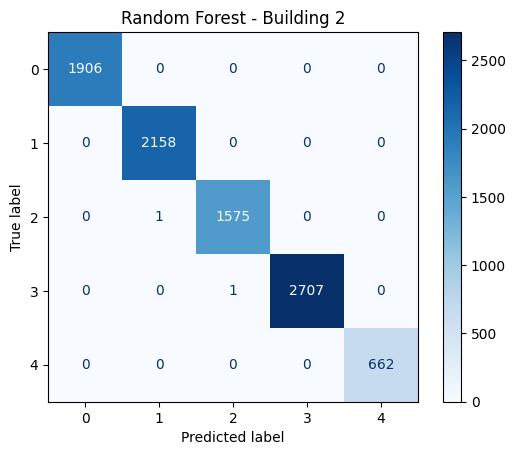

In [36]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

for b, (X, y) in data.items():

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    predictions = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        n_jobs=-1
    )

    ConfusionMatrixDisplay.from_predictions(
        y,
        predictions,
        cmap="Blues"
    )

    plt.title(f"Random Forest - Building {b}")
    plt.show()

## 8. Results and Discussion

All three models achieved very high classification performance across the
three buildings.

Random Forest achieved the highest accuracy among the models implemented
in this notebook for all three buildings.

Gradient Boosting also achieved consistently high performance, while SVM
performed slightly lower overall but remained highly accurate.

The differences between models indicate that ensemble tree-based methods
are particularly effective for the Wi-Fi fingerprint classification
problem.

## 9. Extension Analysis

Random Forest was selected as the additional model for extending the
reference work.

The model was evaluated using the same building-wise datasets and
cross-validation strategy as the other models.

Random Forest achieved the highest accuracy among the models evaluated
in this experiment, suggesting that its ensemble of decision trees is
well suited to the high-dimensional Wi-Fi fingerprint features.

## 10. Limitations

The experiments use the available cleaned version of the dataset.

The results may differ from the reference implementation because of
differences in preprocessing, train/test partitioning, random seeds,
library versions, hyperparameters, or implementation details.

Therefore, differences between the reproduced results and the reference
results should be interpreted in the context of these experimental
differences.

## 11. Conclusion

This project evaluated machine learning approaches for indoor floor
classification using Wi-Fi fingerprint data.

Gradient Boosting, SVM and Random Forest were evaluated independently
for three buildings using stratified 10-fold cross-validation.

All three models achieved high classification performance.

Random Forest achieved the highest accuracy in the experiments conducted
in this notebook and therefore represents a strong extension to the
reference approach.

The results demonstrate the effectiveness of Wi-Fi RSSI fingerprints for
indoor floor-level positioning.